In [4]:
import warnings
warnings.filterwarnings('ignore')
from mp_api.client import MPRester
import pandas as pd
Api_key="HCdJoVajvCUxImHdiNAoWIEoZOHE05XZ"
with MPRester(Api_key) as mpr:
    results = mpr.materials.summary.search(
        band_gap=(0.5,3.5),
        num_elements=(1,3),
        fields=["material_id","formula_pretty","band_gap","formation_energy_per_atom",
                "density","volume"]
    )
rows=[]
for r in results:
    rows.append({
        "id":r.material_id,
        "formula":r.formula_pretty,
        "bandgap":r.band_gap,
        "formation_energy":r.formation_energy_per_atom,
        "density":r.density,
        "volume":r.volume
    })
df=pd.DataFrame(rows)
print(f"Downloaded {len(df)} materials")
print(df.head(10)) # first 10 
#print(df) this will show output of 20194 materials



Retrieving SummaryDoc documents:   0%|          | 0/20194 [00:00<?, ?it/s]

Downloaded 20194 materials
           id  formula  bandgap  formation_energy   density       volume
0    mp-32800    Ac2S3   2.2962         -2.493064  6.535149  1118.407852
1   mp-977351    Ac2S3   3.0275         -2.440364  5.562971   328.464893
2  mp-1183052    AcBO3   0.8071         -2.475390  9.206879    51.548126
3   mp-866101   AcCrO3   2.0031         -3.138972  8.848788    61.362845
4   mp-861502   AcFeO3   0.9888         -2.771539  8.889999    61.797311
5  mp-1183053   AcGaO3   2.8959         -3.063253  9.314495    61.455078
6   mp-861605     AcH3   0.6407         -0.671802  7.784734    49.065716
7   mp-861867     AcI3   2.5892         -1.801003  4.334420   465.636416
8  mp-1183152   AcScO3   3.3847         -3.829060  7.569207    70.191801
9   mp-865028  AcTlTe2   0.6253         -1.251403  8.430613   135.233149


In [5]:
df.to_csv("materials_data.csv",index=False)
print("data saved to materials_data.csv")

data saved to materials_data.csv


In [12]:
import matplotlib.pyplot as plt
print(df.describe())
print(f"\nMaterials with bandgap>2:{len(df[df['bandgap']>2])}")
print(f"most common: {df['formula'].value_counts().head(5)}")

            bandgap  formation_energy       density        volume
count  20194.000000      20194.000000  20194.000000  20194.000000
mean       1.748529         -1.719014      4.567107    578.403810
std        0.828653          0.990598      1.825282    670.207188
min        0.500300         -4.389466      0.020144     16.207758
25%        1.031925         -2.411178      3.295815    211.347612
50%        1.647400         -1.764878      4.299517    371.569747
75%        2.379675         -0.996346      5.598817    709.888184
max        3.499800          4.688205     15.230460  20090.906408

Materials with bandgap>2:7551
most common: formula
ZnS          140
CdI2         122
CeSe2        120
Li7Mn5O12     57
FeOF          48
Name: count, dtype: int64


Original: 20194 materials
Filtered: 19437 materials


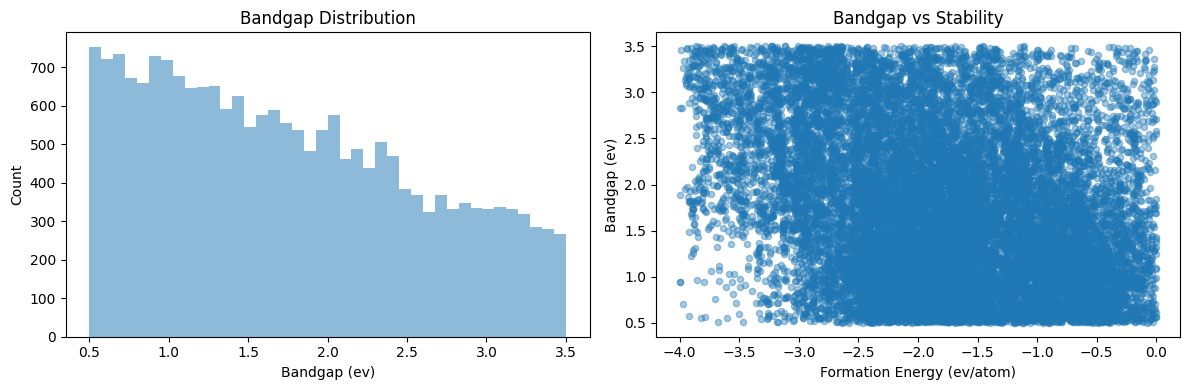

Exploraton plots saved!


In [37]:
#band gap distribution
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].hist(df["bandgap"],bins=40,alpha=0.5)
axes[0].set_xlabel("Bandgap (ev)")
axes[0].set_ylabel("Count")
axes[0].set_title("Bandgap Distribution")
# plot 2
# filter to cleaner data
df_clean = df[
    (df['formation_energy'] >= -4) &   # remove extreme outliers
    (df['formation_energy'] <= 0) &    # unstable materials not useful
    (df['bandgap'] >= 0.5)            # already filtered but double check 
].copy()

print(f"Original: {len(df)} materials")
print(f"Filtered: {len(df_clean)} materials")


axes[1].scatter(df_clean["formation_energy"],df_clean["bandgap"],
                alpha=0.4,s=20)
axes[1].set_xlabel("Formation Energy (ev/atom)")
axes[1].set_ylabel("Bandgap (ev)")
axes[1].set_title("Bandgap vs Stability")
plt.tight_layout()
plt.savefig("data_exploration.png",dpi=150)
plt.show()
print("Exploraton plots saved!")

.There are nearly 750 compounds of Bandgap nearly 0.5 ev
.The second plot is off the Bandgap Stability i filtered it to 19437 materilas and plotted the scattered plot.
.Some materials cluster around low formation energy values, indicating stable compounds.
. Most materials have bandgaps below 2 eV.
. Formation energy and bandgap do not show a strong relationship.
